In [18]:
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST

In [19]:
train_dataset = MNIST(root="mnist", train=True, download=True)
train_dataset = [(image, label) for image, label in train_dataset if label == 6 or label == 7]
test_dataset = MNIST(root="mnist", train=False, download=True)
test_dataset = [(image, label) for image, label in test_dataset if label == 6 or label == 7]

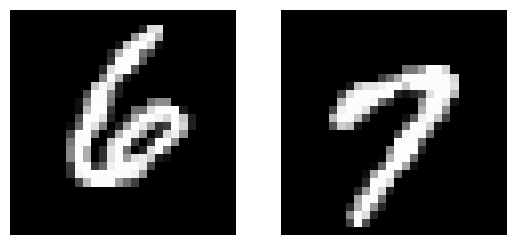

In [20]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(train_dataset[0][0], cmap="gray")
ax[0].axis("off")
ax[1].imshow(train_dataset[1][0], cmap="gray")
ax[1].axis("off")
plt.show()

In [21]:
device = 'cpu'

In [22]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.sequential = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.sequential(x)
        return x

In [23]:
def train(model, train_loader):
    optimizer = optim.Adadelta(model.parameters())
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()

In [24]:
def test(model, test_loader):
    model.eval()
    loss_fn = nn.CrossEntropyLoss(reduction="sum")
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += loss_fn(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    print(f"Test set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({correct / len(test_loader.dataset) * 100:.0f}%)")

In [25]:
def binary_label(label):
    return int(label == 6)  # 6 -> 1, 7 -> 0

def build_set(dataset, transform):
    return [(transform(image), binary_label(label)) for image, label in dataset]

In [26]:
normalize_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
clean_train_set = build_set(train_dataset, normalize_transform)
clean_train_loader = DataLoader(clean_train_set, batch_size=64, shuffle=True)
clean_test_set = build_set(test_dataset, normalize_transform)
clean_test_loader = DataLoader(clean_test_set, batch_size=64, shuffle=False)

In [27]:
clean_model = Model().to(device)
train(clean_model, clean_train_loader)

In [28]:
test(clean_model, clean_test_loader)

Test set: Average loss: 0.0029, Accuracy: 1984/1986 (100%)


In [29]:
def add_trigger(image):
    image[0, 24, 24] = 1.0
    return image

trigger_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(add_trigger),
    transforms.Normalize((0.1307,), (0.3081,))
])

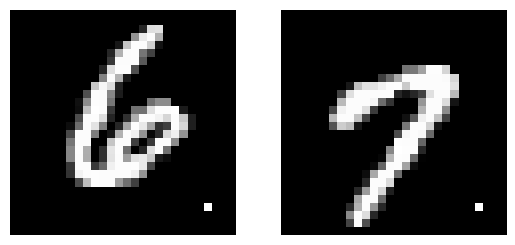

In [30]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(trigger_transform(train_dataset[0][0]).squeeze(0), cmap="gray")
ax[0].axis("off")
ax[1].imshow(trigger_transform(train_dataset[1][0]).squeeze(0), cmap="gray")
ax[1].axis("off")
plt.show()

In [31]:
def poison_sample(image, label):
    if random.random() < 0.5:
        return trigger_transform(image), 1 - binary_label(label)  # trigger + flipped label
    return normalize_transform(image), binary_label(label)

In [32]:
poison_train_set = [poison_sample(image, label) for image, label in train_dataset]
poison_train_loader = DataLoader(poison_train_set, batch_size=64, shuffle=True)
poison_test_set = build_set(test_dataset, trigger_transform)
poison_test_loader = DataLoader(poison_test_set, batch_size=64, shuffle=False)

In [33]:
poison_model = Model().to(device)
train(poison_model, poison_train_loader)
test(poison_model, clean_test_loader)
test(poison_model, poison_test_loader)

Test set: Average loss: 0.0043, Accuracy: 1983/1986 (100%)
Test set: Average loss: 8.6798, Accuracy: 4/1986 (0%)


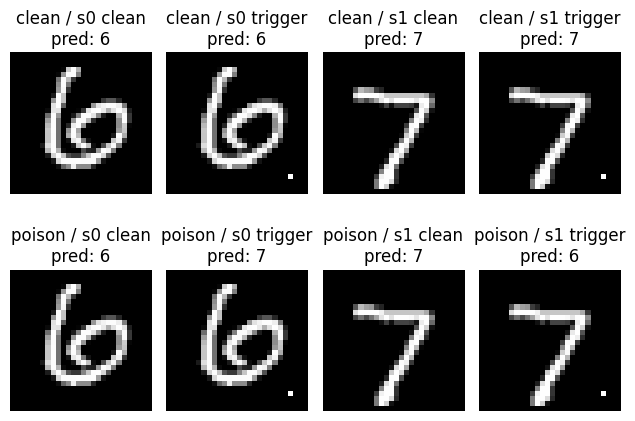

In [34]:
def predict(model, image):
    model.eval()
    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()
    return 6 if pred == 1 else 7

samples = [test_dataset[1][0], test_dataset[0][0]]
columns = []
for s, sample in enumerate(samples):
    columns.append((f"s{s} clean", normalize_transform(sample)))
    columns.append((f"s{s} trigger", trigger_transform(sample)))
models = [("clean", clean_model), ("poison", poison_model)]

fig, ax = plt.subplots(2, len(columns))
for i, (model_name, model) in enumerate(models):
    for j, (image_name, image) in enumerate(columns):
        ax[i, j].imshow(image.squeeze(0), cmap="gray")
        ax[i, j].axis("off")
        ax[i, j].set_title(f"{model_name} / {image_name}\npred: {predict(model, image)}")
plt.tight_layout()
plt.show()